In [1]:
# %%
# Banana subset — exhaustive GridSearchCV on all 60 cores
# Parallelization: 15 outer tasks (3 models × 5 folds) × 4 inner jobs = 60 cores
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, confusion_matrix
)
from sklearn.model_selection import GroupKFold, GridSearchCV

import mne
mne.set_log_level("WARNING")

In [2]:
# %%
PROJECT_ROOT = Path("..").resolve()
DERIVED_ROOT = PROJECT_ROOT / "data" / "derived"
OUT_DIR      = PROJECT_ROOT / "results" / "models"
FIGURE_DIR   = PROJECT_ROOT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Pre-computed banana features from notebook 07b
BP_PATH   = DERIVED_ROOT / "features" / "features_banana_bandpower.csv"
WPLI_PATH = DERIVED_ROOT / "features" / "features_banana_wpli_edges.csv"

# Previous randomized results for comparison
RAND_PATH = OUT_DIR / "results_rf_banana_all.csv"
FULL_PATH = OUT_DIR / "results_rf_nested_groupkfold_Aepoch_BwpliEpochSliding.csv"

OUTER_SPLITS = 5
INNER_SPLITS = 4
SEED         = 0
N_CORES      = os.cpu_count() or 8

N_OUTER_TASKS = 3 * OUTER_SPLITS   # 15
# Distribute cores: outer tasks run in parallel, each gets a slice of cores
N_OUTER_JOBS  = min(N_CORES, N_OUTER_TASKS)   # 15
N_INNER_JOBS  = max(1, N_CORES // N_OUTER_JOBS)  # 4

print(f"Total cores: {N_CORES}")
print(f"Outer parallel tasks: {N_OUTER_JOBS}  ×  inner jobs per task: {N_INNER_JOBS}  =  {N_OUTER_JOBS * N_INNER_JOBS} cores used")

# Full exhaustive grid
PARAM_GRID = {
    "n_estimators":      [200, 400, 600, 1000],
    "max_depth":         [5, 10, 20],
    "min_samples_split": [2, 4, 8, 10],
    "min_samples_leaf":  [1, 2, 3, 4, 5],
    "max_features":      ["sqrt", 0.3, 0.8],
}
n_combos = 1
for v in PARAM_GRID.values():
    n_combos *= len(v)
print(f"Grid combinations: {n_combos}  ×  {INNER_SPLITS} inner folds = {n_combos * INNER_SPLITS:,} fits per (model × fold)")
print(f"Total fits: {n_combos * INNER_SPLITS * N_OUTER_TASKS:,}")

Total cores: 60
Outer parallel tasks: 15  ×  inner jobs per task: 4  =  60 cores used
Grid combinations: 720  ×  4 inner folds = 2,880 fits per (model × fold)
Total fits: 43,200


In [3]:
# %%
# ============================================
# Section 1. Load pre-computed banana features
# ============================================

bp_df   = pd.read_csv(BP_PATH)
wpli_df = pd.read_csv(WPLI_PATH)

# Identify feature columns
bp_cols   = [c for c in bp_df.columns   if c.startswith("bp_")]
wpli_cols = [c for c in wpli_df.columns if c not in {"subject_id", "recording_number",
                                                       "epoch_index_original", "drug"}]

# Align rows (same epoch order as bp_df, which is authoritative for y / groups)
XA = bp_df[bp_cols].to_numpy()
XB = wpli_df[wpli_cols].to_numpy()
XC = np.concatenate([XA, XB], axis=1)

y      = (bp_df["drug"] == "ketamine").astype(int).to_numpy()
groups = bp_df["subject_id"].astype(str).to_numpy()

@dataclass(frozen=True)
class Spec:
    X: np.ndarray
    name: str

specs = [
    Spec(XA, "A_banana_bandpower"),
    Spec(XB, "B_banana_wpli"),
    Spec(XC, "C_banana_A_plus_B"),
]

for s in specs:
    print(f"{s.name}: {s.X.shape}")

A_banana_bandpower: (276, 16)
B_banana_wpli: (276, 18)
C_banana_A_plus_B: (276, 34)


In [ ]:
# %%
# ============================================
# Section 2. Exhaustive grid search — nested CV
# ============================================

outer_cv = GroupKFold(n_splits=OUTER_SPLITS)
splits   = list(outer_cv.split(XA, y, groups))


def fit_eval_one(X: np.ndarray, model_name: str,
                 fold: int, tr: np.ndarray, te: np.ndarray) -> tuple:
    inner_cv = GroupKFold(n_splits=INNER_SPLITS)
    gtr, gte = groups[tr], groups[te]

    gs = GridSearchCV(
        RandomForestClassifier(
            random_state=SEED,
            class_weight="balanced_subsample",
            n_jobs=1,
        ),
        param_grid=PARAM_GRID,
        cv=inner_cv,
        scoring="balanced_accuracy",
        n_jobs=N_INNER_JOBS,
        refit=True,
    )
    gs.fit(X[tr], y[tr], groups=gtr)
    best  = gs.best_estimator_
    proba = best.predict_proba(X[te])[:, 1]
    yhat  = (proba >= 0.5).astype(int)

    try:
        auc = float(roc_auc_score(y[te], proba))
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y[te], yhat, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (np.nan,) * 4

    fold_row = {
        "model": model_name, "fold": fold,
        "n_test": int(len(te)), "n_test_subjects": int(len(np.unique(gte))),
        "accuracy": float(accuracy_score(y[te], yhat)),
        "balanced_accuracy": float(balanced_accuracy_score(y[te], yhat)),
        "roc_auc": auc,
        "tn": float(tn), "fp": float(fp), "fn": float(fn), "tp": float(tp),
        "best_score_inner": float(gs.best_score_),
    }
    pred_rows = [
        {"model": model_name, "fold": fold, "subject_id": gte[i],
         "y_true": int(y[te][i]), "y_proba": float(proba[i]), "y_pred": int(yhat[i])}
        for i in range(len(te))
    ]
    param_row = {"model": model_name, "fold": fold,
                 "best_score_inner": float(gs.best_score_), **gs.best_params_}
    return fold_row, pred_rows, param_row


tasks = [
    (s.X, s.name, fold, tr, te)
    for s in specs
    for fold, (tr, te) in enumerate(splits, start=1)
]

results = Parallel(n_jobs=N_OUTER_JOBS, prefer="processes")(
    delayed(fit_eval_one)(*t) for t in tasks
)

folds_gs  = pd.DataFrame([r[0] for r in results]).sort_values(["model", "fold"]).reset_index(drop=True)
preds_gs  = pd.DataFrame([pr for r in results for pr in r[1]])
params_gs = pd.DataFrame([r[2] for r in results]).sort_values(["model", "fold"]).reset_index(drop=True)

print("Done.")
display(folds_gs)

In [ ]:
# %%
# Save
folds_gs.to_csv(OUT_DIR / "results_rf_banana_gridsearch.csv", index=False)
preds_gs.to_csv(OUT_DIR / "predictions_rf_banana_gridsearch.csv", index=False)
params_gs.to_csv(OUT_DIR / "best_params_rf_banana_gridsearch.csv", index=False)
print("Saved.")

In [ ]:
# %%
# ============================================
# Section 3. Three-way comparison:
# full 62ch  |  banana RandomizedSearch (N=50)  |  banana GridSearch (exhaustive)
# ============================================

full = pd.read_csv(FULL_PATH)
rand = pd.read_csv(RAND_PATH)

rows = []
for label, df_m, n_feat in [
    ("A full62ch",  full[full["model"] == "A_bandpower_epoch"],           26),
    ("B full62ch",  full[full["model"] == "B_wpli_edges_epoch_sliding"],  5673),
    ("C full62ch",  full[full["model"] == "C_AplusB_epoch_sliding"],      5699),
    ("A banana rand", rand[rand["model"] == "A_banana_bandpower"],        16),
    ("B banana rand", rand[rand["model"] == "B_banana_wpli"],             18),
    ("C banana rand", rand[rand["model"] == "C_banana_A_plus_B"],         34),
    ("A banana grid", folds_gs[folds_gs["model"] == "A_banana_bandpower"], 16),
    ("B banana grid", folds_gs[folds_gs["model"] == "B_banana_wpli"],      18),
    ("C banana grid", folds_gs[folds_gs["model"] == "C_banana_A_plus_B"],  34),
]:
    rows.append({
        "model":     label,
        "n_feat":    n_feat,
        "bacc_mean": round(float(df_m["balanced_accuracy"].mean()), 4),
        "bacc_std":  round(float(df_m["balanced_accuracy"].std()),  4),
        "auc_mean":  round(float(df_m["roc_auc"].mean()),           4),
        "auc_std":   round(float(df_m["roc_auc"].std()),            4),
    })

comparison = pd.DataFrame(rows)
print("\n=== Three-way comparison ===")
display(comparison.set_index("model").round(4))

In [ ]:
# %%
# ============================================
# Section 4. Plot — per-fold balanced accuracy, all variants
# ============================================

plot_specs = [
    # (label, series, color, marker)
    ("A full",       full[full["model"]=="A_bandpower_epoch"]["balanced_accuracy"].values,          "steelblue", "o"),
    ("B full",       full[full["model"]=="B_wpli_edges_epoch_sliding"]["balanced_accuracy"].values,  "coral",     "o"),
    ("C full",       full[full["model"]=="C_AplusB_epoch_sliding"]["balanced_accuracy"].values,      "purple",    "o"),
    ("A rand",       rand[rand["model"]=="A_banana_bandpower"]["balanced_accuracy"].values,           "steelblue", "s"),
    ("B rand",       rand[rand["model"]=="B_banana_wpli"]["balanced_accuracy"].values,                "coral",     "s"),
    ("C rand",       rand[rand["model"]=="C_banana_A_plus_B"]["balanced_accuracy"].values,            "purple",    "s"),
    ("A grid",       folds_gs[folds_gs["model"]=="A_banana_bandpower"]["balanced_accuracy"].values,   "steelblue", "^"),
    ("B grid",       folds_gs[folds_gs["model"]=="B_banana_wpli"]["balanced_accuracy"].values,        "coral",     "^"),
    ("C grid",       folds_gs[folds_gs["model"]=="C_banana_A_plus_B"]["balanced_accuracy"].values,    "purple",    "^"),
]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (label, vals, color, marker) in enumerate(plot_specs):
    jitter = (np.random.RandomState(i).rand(len(vals)) - 0.5) * 0.10
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=color, s=55, zorder=3, alpha=0.9, marker=marker)
    ax.hlines(vals.mean(), i - 0.22, i + 0.22, colors=color, linewidths=2.5)

ax.axhline(0.5, linestyle=":", color="grey", linewidth=1)
ax.set_xticks(range(len(plot_specs)))
ax.set_xticklabels([p[0] for p in plot_specs], fontsize=10, rotation=20, ha="right")
ax.set_ylabel("Balanced accuracy", fontsize=12)
ax.set_title(
    "Per-fold balanced accuracy — full 62ch vs banana 4ch\n"
    "Circle=full | Square=banana rand N=50 | Triangle=banana grid (3000 combos)",
    fontsize=11
)
ax.set_ylim(0.35, 1.0)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="o", color="grey", label="full 62ch",    linestyle="None", markersize=8),
    Line2D([0],[0], marker="s", color="grey", label="banana rand",  linestyle="None", markersize=8),
    Line2D([0],[0], marker="^", color="grey", label="banana grid",  linestyle="None", markersize=8),
    Line2D([0],[0], color="steelblue", label="A (bandpower)", linewidth=3),
    Line2D([0],[0], color="coral",     label="B (wPLI)",      linewidth=3),
    Line2D([0],[0], color="purple",    label="C (A+B)",        linewidth=3),
]
ax.legend(handles=legend_elements, fontsize=9, ncol=2, loc="upper right")
fig.tight_layout()

out = FIGURE_DIR / "banana_gridsearch_comparison.png"
fig.savefig(out, dpi=150)
print("Saved:", out)
plt.close(fig)

In [ ]:
# %%
# ============================================
# Section 5. HPO gain: grid vs randomized (banana only)
# ============================================

print("HPO gain (grid − randomized, balanced accuracy):")
for model_key, label in [
    ("A_banana_bandpower", "A banana"),
    ("B_banana_wpli",      "B banana"),
    ("C_banana_A_plus_B",  "C banana"),
]:
    rand_mean = rand[rand["model"] == model_key]["balanced_accuracy"].mean()
    grid_mean = folds_gs[folds_gs["model"] == model_key]["balanced_accuracy"].mean()
    delta     = grid_mean - rand_mean
    print(f"  {label}: rand={rand_mean:.4f}  grid={grid_mean:.4f}  Δ={delta:+.4f}")

print()
print("Best params per model (grid search):")
display(params_gs[["model","fold","best_score_inner","n_estimators",
                   "max_depth","max_features","min_samples_split","min_samples_leaf"]])

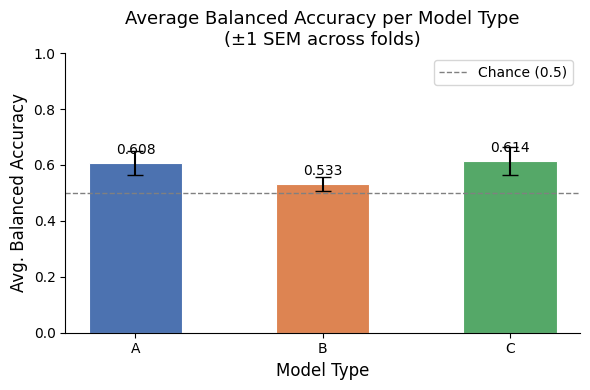

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

csv_data = """model,fold,n_test,n_test_subjects,accuracy,balanced_accuracy,roc_auc,tn,fp,fn,tp,best_score_inner
A_banana_bandpower,1,56,2,0.5714285714285714,0.5714285714285714,0.7742346938775511,6.0,22.0,2.0,26.0,0.6611029009304872
A_banana_bandpower,2,55,2,0.7272727272727273,0.7314814814814814,0.8280423280423281,14.0,14.0,1.0,26.0,0.5444818463783981
A_banana_bandpower,3,54,2,0.7037037037037037,0.6910344827586207,0.76,25.0,4.0,12.0,13.0,0.5816798941798942
A_banana_bandpower,4,56,2,0.5357142857142857,0.5357142857142857,0.6288265306122449,28.0,0.0,26.0,2.0,0.6262584382411969
A_banana_bandpower,5,55,2,0.509090909090909,0.5092592592592593,0.6322751322751323,14.0,14.0,13.0,14.0,0.6748100255427842
B_banana_wpli,1,56,2,0.5714285714285714,0.5714285714285714,0.6428571428571428,12.0,16.0,8.0,20.0,0.4890448823207444
B_banana_wpli,2,55,2,0.4727272727272727,0.4715608465608465,0.5555555555555555,15.0,13.0,16.0,11.0,0.5654625068418172
B_banana_wpli,3,54,2,0.5370370370370371,0.5275862068965518,0.5296551724137931,19.0,10.0,15.0,10.0,0.611276455026455
B_banana_wpli,4,56,2,0.6071428571428571,0.6071428571428572,0.6683673469387756,18.0,10.0,12.0,16.0,0.5528562306148513
B_banana_wpli,5,55,2,0.4909090909090909,0.4887566137566137,0.5238095238095237,17.0,11.0,17.0,10.0,0.6295130906768838
C_banana_A_plus_B,1,56,2,0.5535714285714286,0.5535714285714286,0.6811224489795918,4.0,24.0,1.0,27.0,0.6394086389345011
C_banana_A_plus_B,2,55,2,0.7636363636363637,0.7665343915343915,0.8346560846560847,17.0,11.0,2.0,25.0,0.567948595146871
C_banana_A_plus_B,3,54,2,0.7222222222222222,0.7055172413793103,0.8096551724137931,27.0,2.0,13.0,12.0,0.6086309523809523
C_banana_A_plus_B,4,56,2,0.5357142857142857,0.5357142857142857,0.6683673469387755,28.0,0.0,26.0,2.0,0.6344973544973544
C_banana_A_plus_B,5,55,2,0.509090909090909,0.5092592592592593,0.6415343915343915,14.0,14.0,13.0,14.0,0.682667168399927"""

df = pd.read_csv(StringIO(csv_data))

df["model_type"] = df["model"].str[0]  # Extract A / B / C
means = df.groupby("model_type")["balanced_accuracy"].mean()
sems  = df.groupby("model_type")["balanced_accuracy"].sem()

colors = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(means.index, means.values, yerr=sems.values,
              color=[colors[m] for m in means.index],
              capsize=6, width=0.5, edgecolor="white", linewidth=0.8)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
ax.set_ylim(0, 1)
ax.set_xlabel("Model Type", fontsize=12)
ax.set_ylabel("Avg. Balanced Accuracy", fontsize=12)
ax.set_title("Average Balanced Accuracy per Model Type\n(±1 SEM across folds)", fontsize=13)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()